# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023.

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately.
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [ ]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [ ]:
df = pd.read_csv("cleaned_aviation_data.csv")
df.head()

,Event.Date,Make,Model,Aircraft.damage,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Amateur.Built,Weather.Condition,Broad.phase.of.flight,Purpose.of.flight,Engine.Type,Number.of.Engines,Total.People,Fatality.Rate,Serious.Injury.Rate,Destroyed,Aircraft.Type
0,1983-01-01,CESSNA,182P,Substantial,0.0,0.0,1.0,3.0,No,VMC,Nan,Personal,Reciprocating,1.0,4.0,0.0,0.0,0,CESSNA 182P
1,1983-01-01,CESSNA,182RG,Substantial,0.0,0.0,0.0,2.0,No,VMC,Nan,Personal,Reciprocating,1.0,2.0,0.0,0.0,0,CESSNA 182RG
2,1983-01-01,CESSNA,182P,Substantial,0.0,0.0,0.0,1.0,No,VMC,Nan,Personal,Reciprocating,1.0,1.0,0.0,0.0,0,CESSNA 182P
3,1983-01-01,PIPER,PA-28R-200,Substantial,0.0,0.0,2.0,0.0,No,VMC,Nan,Personal,Reciprocating,1.0,2.0,0.0,0.0,0,PIPER PA-28R-200
4,1983-01-01,CESSNA,140,Substantial,0.0,0.0,0.0,2.0,No,VMC,Nan,Instructional,Reciprocating,1.0,2.0,0.0,0.0,0,CESSNA 140


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63130 entries, 0 to 63129
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Date              63130 non-null  object 
 1   Make                    63130 non-null  object 
 2   Model                   63130 non-null  object 
 3   Aircraft.damage         61485 non-null  object 
 4   Total.Fatal.Injuries    54859 non-null  float64
 5   Total.Serious.Injuries  54271 non-null  float64
 6   Total.Minor.Injuries    54793 non-null  float64
 7   Total.Uninjured         59527 non-null  float64
 8   Amateur.Built           63130 non-null  object 
 9   Weather.Condition       63130 non-null  object 
 10  Broad.phase.of.flight   63130 non-null  object 
 11  Purpose.of.flight       60549 non-null  object 
 12  Engine.Type             61419 non-null  object 
 13  Number.of.Engines       63130 non-null  float64
 14  Total.People            63130 non-null

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.

In [ ]:
#Create aircraft size groups (given threshold = 20)
df['Aircraft_Size'] = df['Total.People'].apply(lambda x: 'Small' if x < 20 else 'Large')

In [ ]:
df['Aircraft_Size'].value_counts()

Aircraft_Size
Small    61110
Large     2020
Name: count, dtype: int64

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [ ]:
df['Human_Injury_Risk'] = df['Fatality.Rate'] + df['Serious.Injury.Rate']

In [ ]:
# Aggregate by Make and Aircraft Size
make_risk = df.groupby(['Aircraft_Size', 'Make']).agg(
    mean_injury_risk=('Human_Injury_Risk', 'mean'),
    incidents=('Make', 'count')
).reset_index()

In [ ]:
# filter
make_risk = make_risk[make_risk['incidents'] >= 10]

In [ ]:
# Get top 15 safest small aircraft
small_makes = make_risk[make_risk['Aircraft_Size'] == 'Small']

top_small_makes = small_makes.sort_values('mean_injury_risk').head(15)

In [ ]:
# Get top 15 safest large aircraft
large_makes = make_risk[make_risk['Aircraft_Size'] == 'Large']

top_large_makes = large_makes.sort_values('mean_injury_risk').head(15)

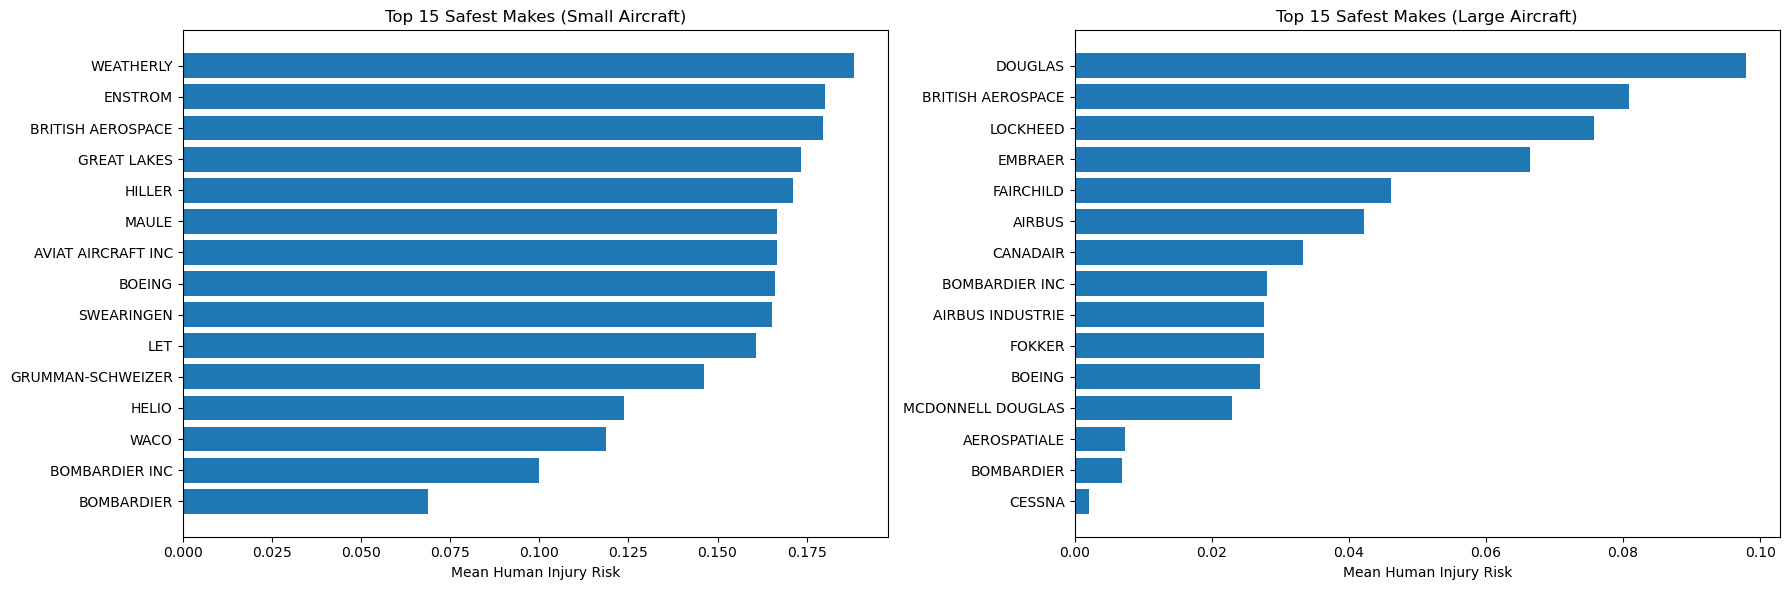

In [ ]:
# Plot side-by-side comparison

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Small aircraft plot
axes[0].barh(top_small_makes['Make'], top_small_makes['mean_injury_risk'])
axes[0].set_title('Top 15 Safest Makes (Small Aircraft)')
axes[0].set_xlabel('Mean Human Injury Risk')

# Large aircraft plot
axes[1].barh(top_large_makes['Make'], top_large_makes['mean_injury_risk'])
axes[1].set_title('Top 15 Safest Makes (Large Aircraft)')
axes[1].set_xlabel('Mean Human Injury Risk')

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [ ]:
#Filter to small aircraft only
small_df = df[df['Aircraft_Size'] == 'Small']

In [ ]:
# Identify 10 safest makes
top_10_makes = (
    small_df.groupby('Make')['Human_Injury_Risk']
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [ ]:
# Filter dataset to only those makes
plot_df = small_df[small_df['Make'].isin(top_10_makes)]

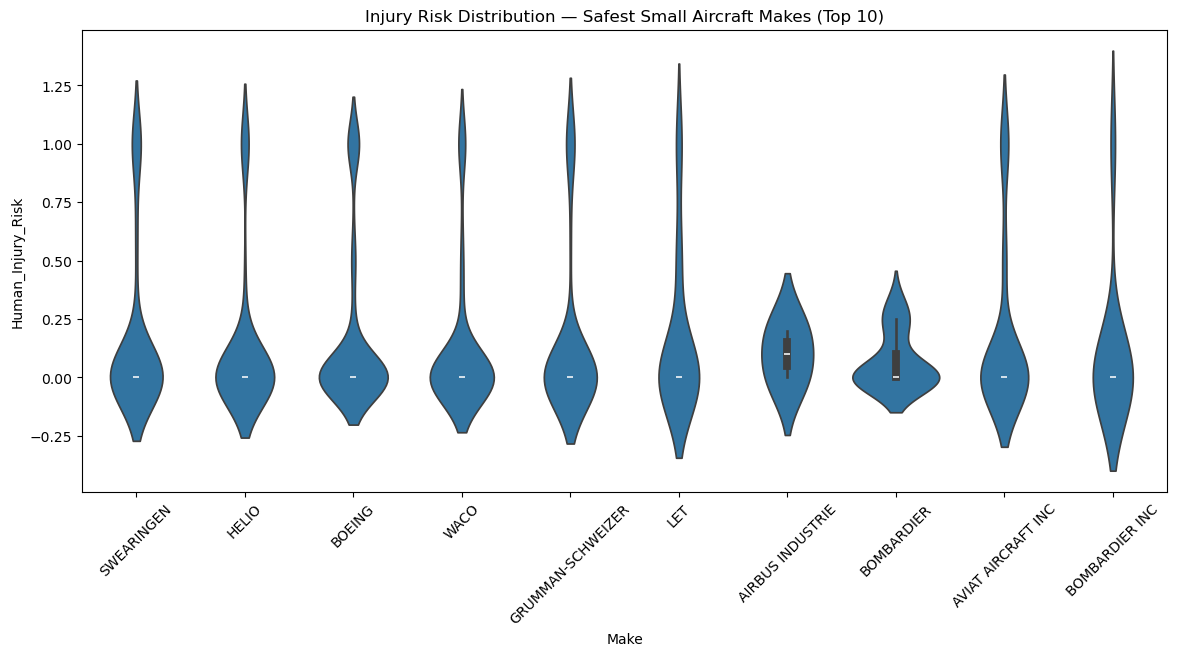

In [ ]:
# violin plot

plt.figure(figsize=(14,6))

sns.violinplot(
    data=plot_df,
    x='Make',
    y='Human_Injury_Risk'
)

plt.xticks(rotation=45)
plt.title('Injury Risk Distribution — Safest Small Aircraft Makes (Top 10)')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [ ]:
import numpy as np

df['Human_Injury_Risk'] = df['Human_Injury_Risk'].replace([np.inf, -np.inf], np.nan)

In [ ]:
# filter large aircraft
large_df = df[df['Aircraft_Size'] == 'Large']

In [ ]:
# Get 10 safest makes
top_10_large_makes = (
    large_df.groupby('Make')['Human_Injury_Risk']
    .mean()
    .sort_values()
    .head(10)
    .index
)

In [ ]:
#Filter dataset for those makes
plot_df_large = large_df[large_df['Make'].isin(top_10_large_makes)]

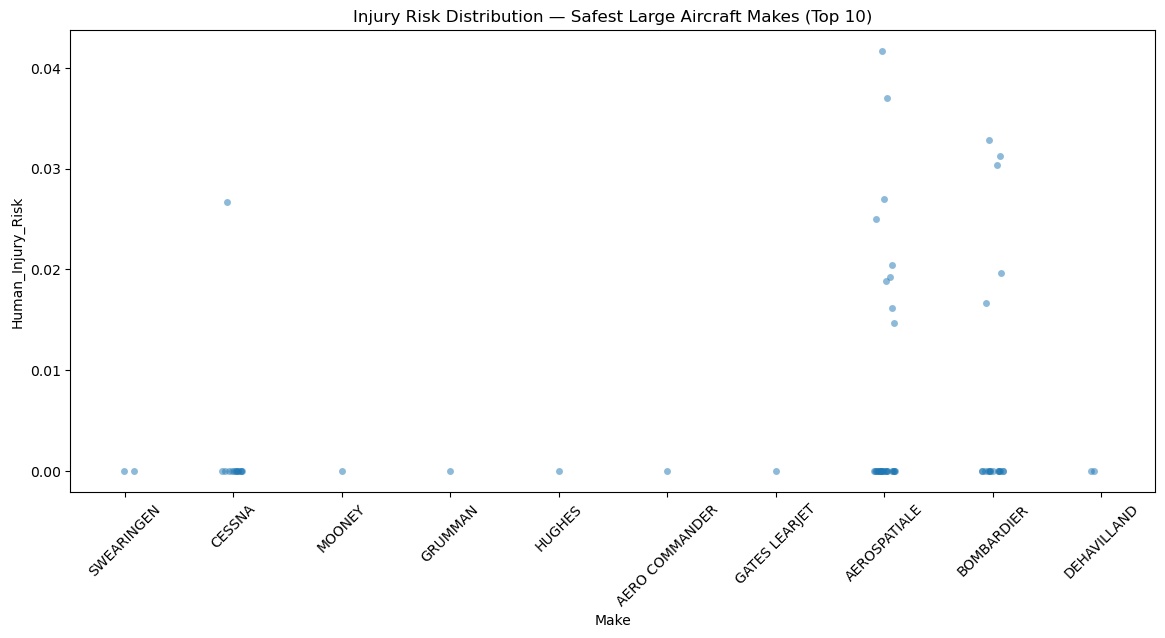

In [ ]:
#Stripplot
plt.figure(figsize=(14,6))

sns.stripplot(
    data=plot_df_large,
    x='Make',
    y='Human_Injury_Risk',
    jitter=True,
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title('Injury Risk Distribution — Safest Large Aircraft Makes (Top 10)')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.**

Sort your results and keep the lowest 15.

In [ ]:
# small aircraft — destruction rate by Make
small_df = df[df['Aircraft_Size'] == 'Small']

small_destroy_rate = (
    small_df.groupby('Make')['Destroyed']
    .mean()
    .reset_index(name='destruction_rate')
)

In [ ]:
# get lowest 15
top_15_small = (
    small_destroy_rate
    .sort_values('destruction_rate')
    .head(15)
)
top_15_small

,Make,destruction_rate
7,AIRBUS INDUSTRIE,0.000000
19,BOMBARDIER,0.000000
40,FOKKER,0.000000
45,GRUMMAN ACFT ENG COR-SCHWEIZER,0.000000
13,BALLOON WORKS,0.027027
9,AMERICAN CHAMPION AIRCRAFT,0.037736
11,AVIAT AIRCRAFT INC,0.039474
30,DEHAVILLAND,0.040816
6,AIRBUS,0.043478
20,BOMBARDIER INC,0.052632


In [ ]:
# Large aircraft — destruction rate by Make
large_df = df[df['Aircraft_Size'] == 'Large']

large_destroy_rate = (
    large_df.groupby('Make')['Destroyed']
    .mean()
    .reset_index(name='destruction_rate')
)

In [ ]:
# get lowest 15

top_15_large = (
    large_destroy_rate
    .sort_values('destruction_rate')
    .head(15)
)
top_15_large

,Make,destruction_rate
0,AERO COMMANDER,0.000000
1,AEROSPATIALE,0.000000
7,BOMBARDIER,0.000000
13,DEHAVILLAND,0.000000
24,MOONEY,0.000000
26,RAYTHEON AIRCRAFT COMPANY,0.000000
20,HUGHES,0.000000
18,GATES LEARJET,0.000000
27,SWEARINGEN,0.000000
8,BOMBARDIER INC,0.022727


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

Large aircrafts show remarkably that they are more consistent when it comes to safety . Most major manufacturers maintain destruction rates below 3% and injury risks under 10%. For insurers, Aero Commander, Bombardier, Airbus Industrie, and Fokker are top recommendations, showing zero destruction rates and low injury variance.

Small aircraft tell a different story. Even top performers show injury risks of 15-25%. Operational factors like weather and pilot skill appear to matter more than manufacturer alone. Cessna and Piper show moderate baseline risk but extreme variability.

Safest overall makes: Airbus Industrie and Bombardier excel across both categories with zero destruction rates and consistently low injury patterns.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [ ]:
#Filter large aircraft
large_df = df[df['Aircraft_Size'] == 'Large']

In [ ]:
# Create injury metric
large_df['Injury_Risk'] = large_df['Fatality.Rate'] + large_df['Serious.Injury.Rate']

C:\Users\User\AppData\Local\Temp\ipykernel_18876\1535422692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  large_df['Injury_Risk'] = large_df['Fatality.Rate'] + large_df['Serious.Injury.Rate']


In [ ]:
#Filter Makes with at least 10 observations
valid_makes = large_df.groupby('Make').filter(lambda x: len(x) >= 10)

In [ ]:
# Mean fatal/serious injury fraction by Make
mean_risk = (
    valid_makes.groupby('Make')['Injury_Risk']
    .mean()
    .sort_values()
    .reset_index()
)

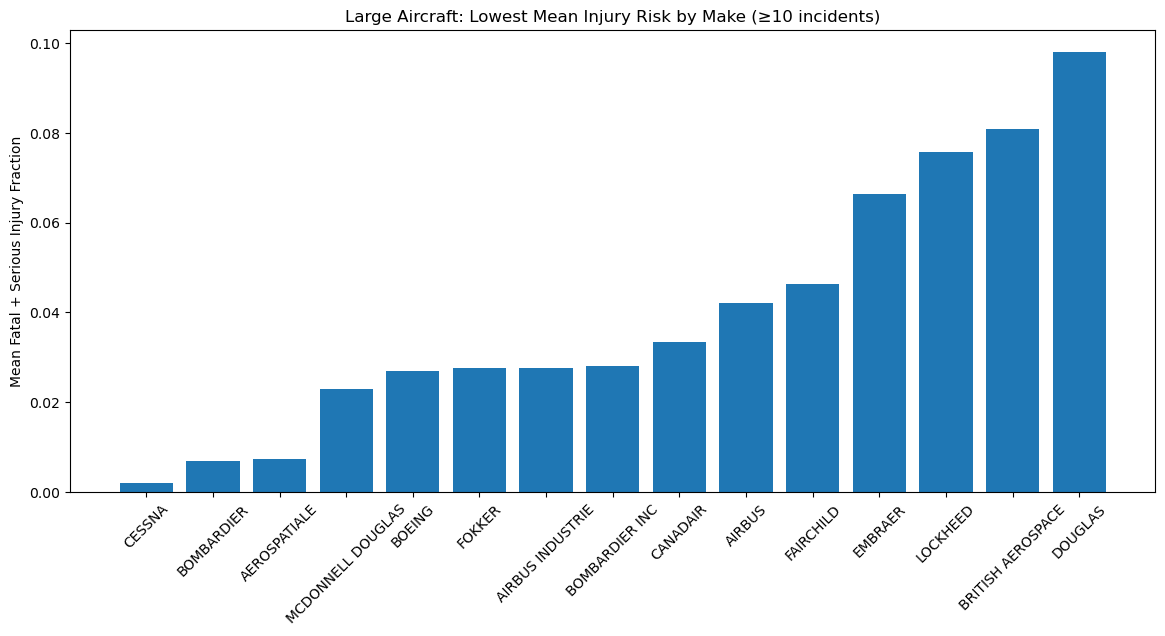

In [ ]:
#Plot mean injury risk (Large aircraft)

plt.figure(figsize=(14,6))

plt.bar(mean_risk['Make'][:15], mean_risk['Injury_Risk'][:15])
plt.xticks(rotation=45)
plt.ylabel('Mean Fatal + Serious Injury Fraction')
plt.title('Large Aircraft: Lowest Mean Injury Risk by Make (≥10 incidents)')
plt.show()

In [ ]:
#top 10 safest makes:
top_10_makes = mean_risk.head(10)['Make']

plot_df = valid_makes[valid_makes['Make'].isin(top_10_makes)]

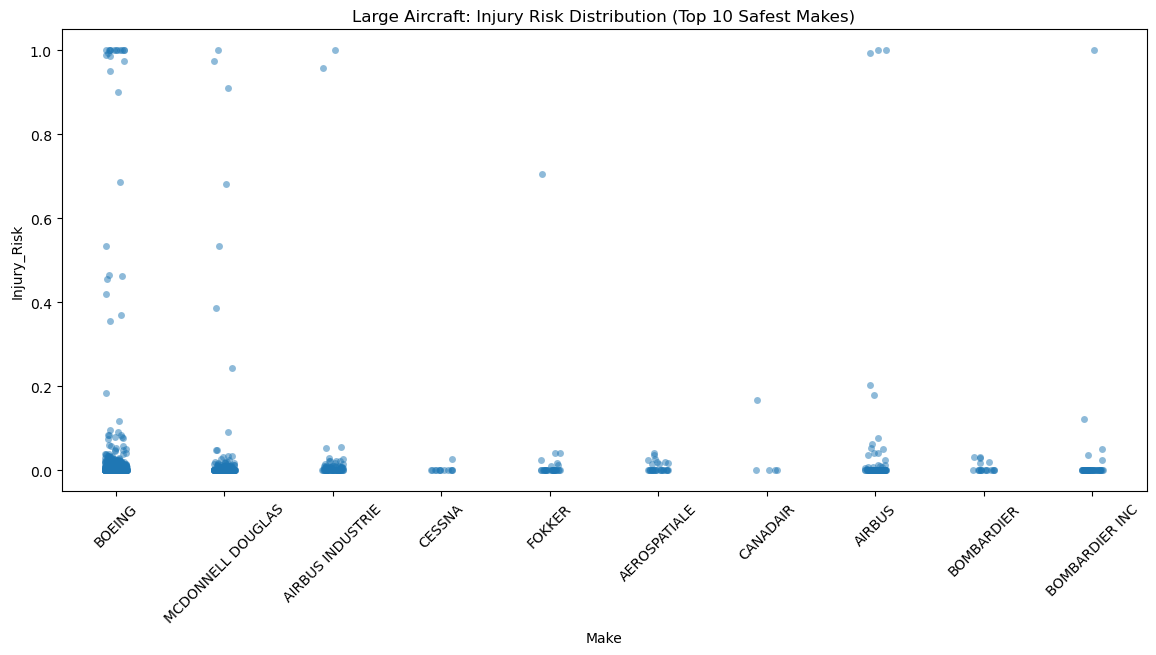

In [ ]:
# Distribution plot (Stripplot)

plt.figure(figsize=(14,6))

sns.stripplot(
    data=plot_df,
    x='Make',
    y='Injury_Risk',
    jitter=True,
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title('Large Aircraft: Injury Risk Distribution (Top 10 Safest Makes)')
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [ ]:
#Filter small aircraft
small_df = df[df['Aircraft_Size'] == 'Small']

In [ ]:
# Create injury metric
small_df['Injury_Risk'] = small_df['Fatality.Rate'] + small_df['Serious.Injury.Rate']

C:\Users\User\AppData\Local\Temp\ipykernel_18876\3292957501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_df['Injury_Risk'] = small_df['Fatality.Rate'] + small_df['Serious.Injury.Rate']


In [ ]:
#Filter Makes with at least 10 observations
valid_small = small_df.groupby('Make').filter(lambda x: len(x) >= 10)

In [ ]:
#mean injury risk per Make
mean_small = (
    valid_small.groupby('Make')['Injury_Risk']
    .mean()
    .sort_values()
    .reset_index()
)

In [ ]:
#top 10 safest makes:
top_10_small = mean_small.head(10)
plot_small = valid_small[valid_small['Make'].isin(top_10_small['Make'])]

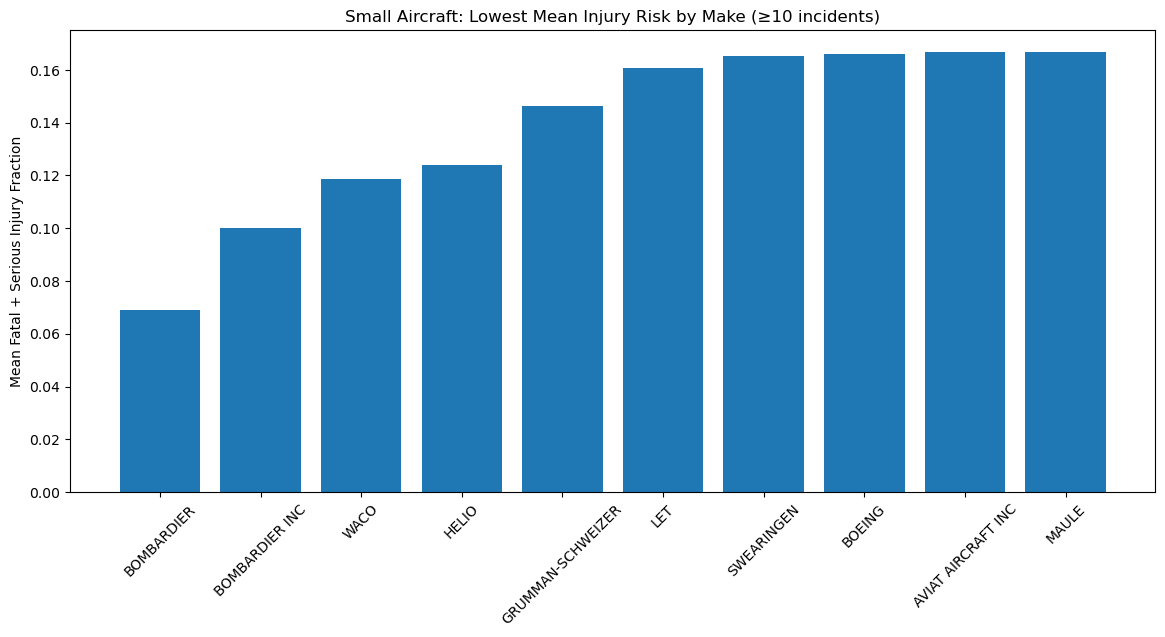

In [ ]:
#plot bar chart

plt.figure(figsize=(14,6))

plt.bar(top_10_small['Make'], top_10_small['Injury_Risk'])

plt.xticks(rotation=45)
plt.ylabel('Mean Fatal + Serious Injury Fraction')
plt.title('Small Aircraft: Lowest Mean Injury Risk by Make (≥10 incidents)')
plt.show()


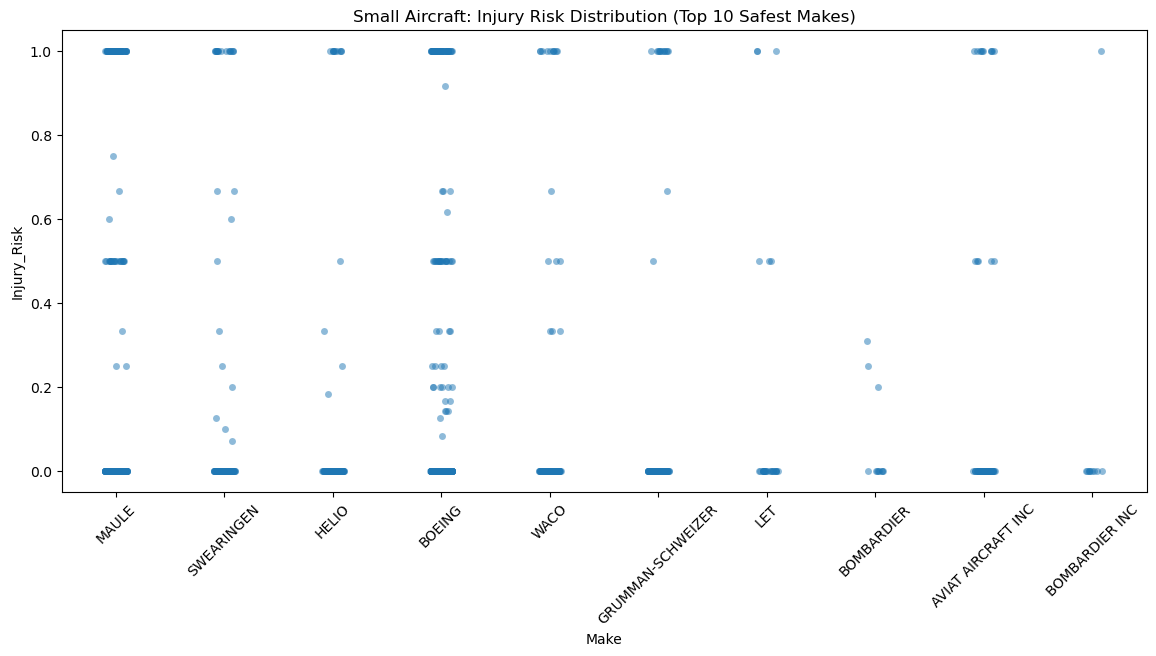

In [ ]:
# Distribution plot (stripplot)
plt.figure(figsize=(14,6))

sns.stripplot(
    data=plot_small,
    x='Make',
    y='Injury_Risk',
    jitter=True,
    alpha=0.5
)

plt.xticks(rotation=45)
plt.title('Small Aircraft: Injury Risk Distribution (Top 10 Safest Makes)')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Large aircraft manufacturers consistently demonstrate lower and more stable injury rates compared to those of smaller aircraft. However, distributional analysis reveals that even among the safest brands, occasional high-risk incidents still occur, which proves that average values alone are insufficient for a complete risk assessment. To make more robust insurance decisions, it is critical to evaluate both the mean safety rankings and the specific variance found within the historical performance data.

Small aircraft experience much greater variability in fatal and serious injury rates than large aircraft. While the top 10 safest makes achieve a low average injury risk, their distribution plots reveal a wide spread of outcomes, indicating inconsistent safety performance. This volatility suggests that small aircraft risk is heavily influenced by external operational conditions rather than just airframe design. Consequently, relying solely on manufacturer averages is insufficient for a reliable safety assessment; insurers must also account for this high distributional variance.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

Will do - Weather Condition vs Aircraft Damage & Injury

In [ ]:
#
df['Injury_Risk'] = df['Fatality.Rate'] + df['Serious.Injury.Rate']

In [ ]:
# Group by Weather Condition
weather_analysis = df.groupby('Weather.Condition').agg(
    mean_injury_risk=('Injury_Risk', 'mean'),
    mean_destroyed=('Destroyed', 'mean'),
    incidents=('Weather.Condition', 'count')
).reset_index()


In [ ]:
#Filter for reliability (≥10 incidents)
weather_analysis = weather_analysis[weather_analysis['incidents'] >= 10]


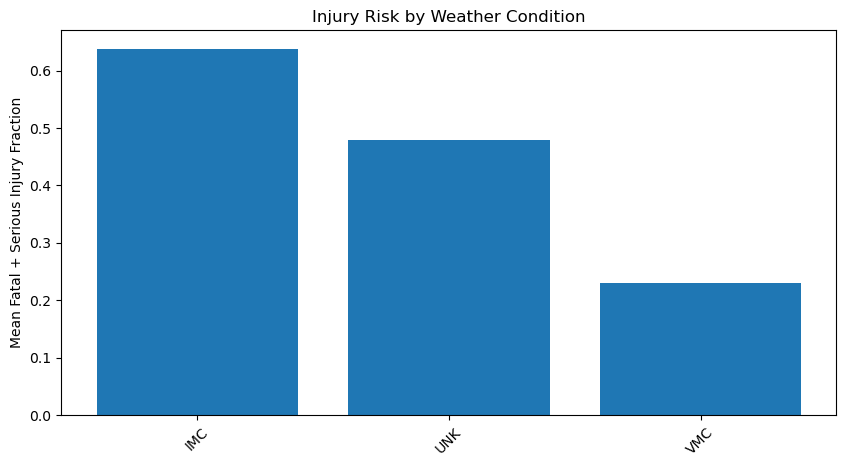

In [ ]:
#visualise

plt.figure(figsize=(10,5))

plt.bar(weather_analysis['Weather.Condition'], weather_analysis['mean_injury_risk'])

plt.title('Injury Risk by Weather Condition')
plt.ylabel('Mean Fatal + Serious Injury Fraction')
plt.xticks(rotation=45)
plt.show()

Conclusion from the above.
Poor weather conditions eg IMC show higher injury and destruction rates.
VMC (clear weather) typically shows lower severity outcomes.